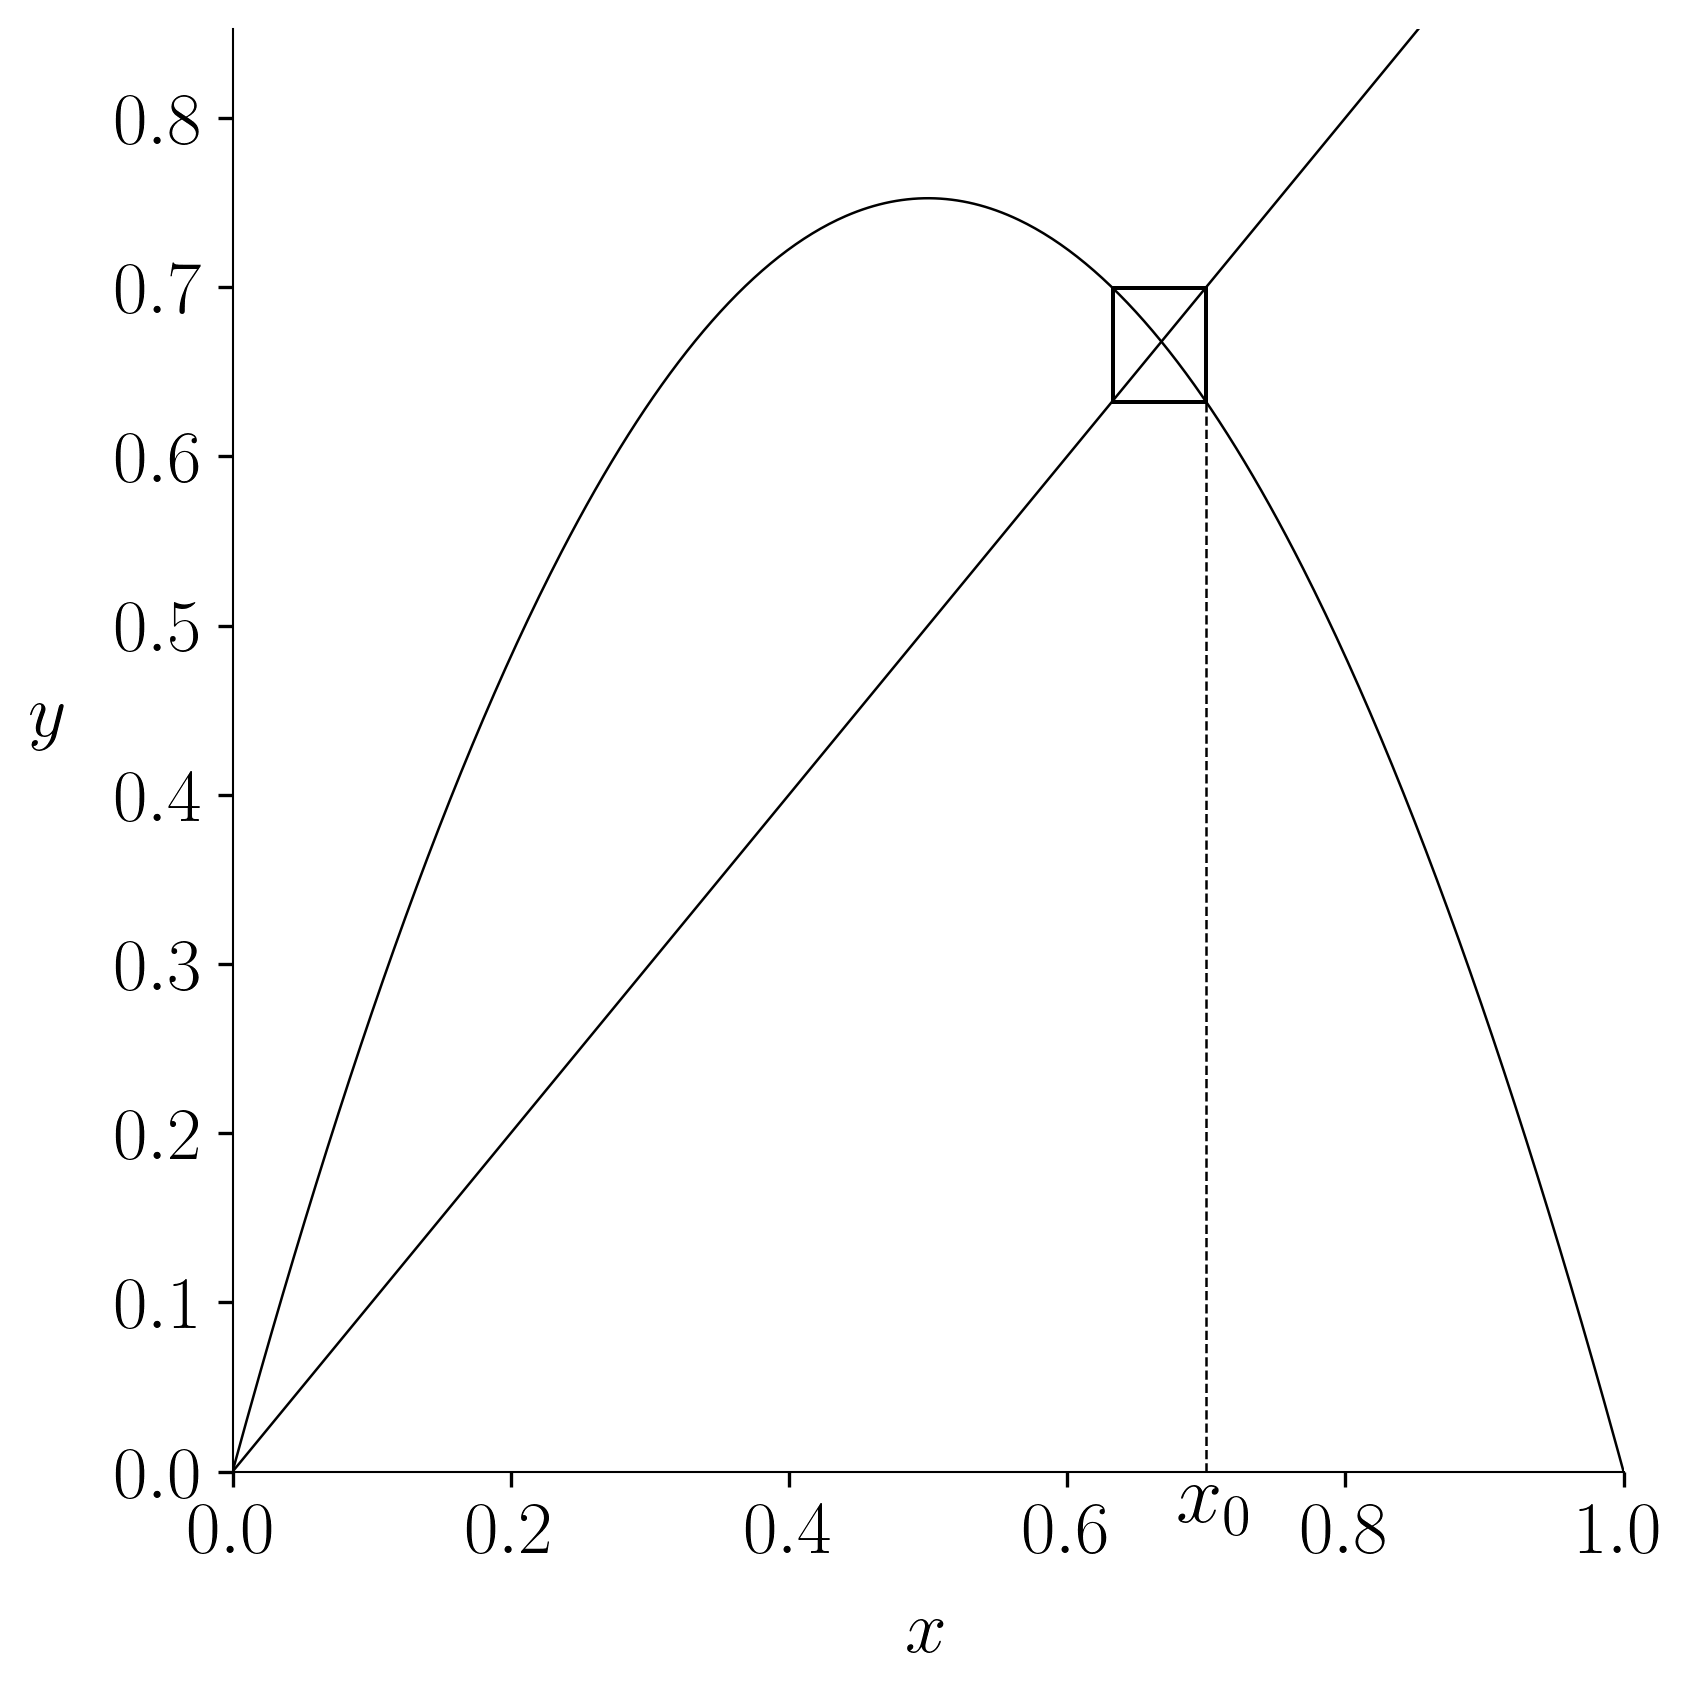

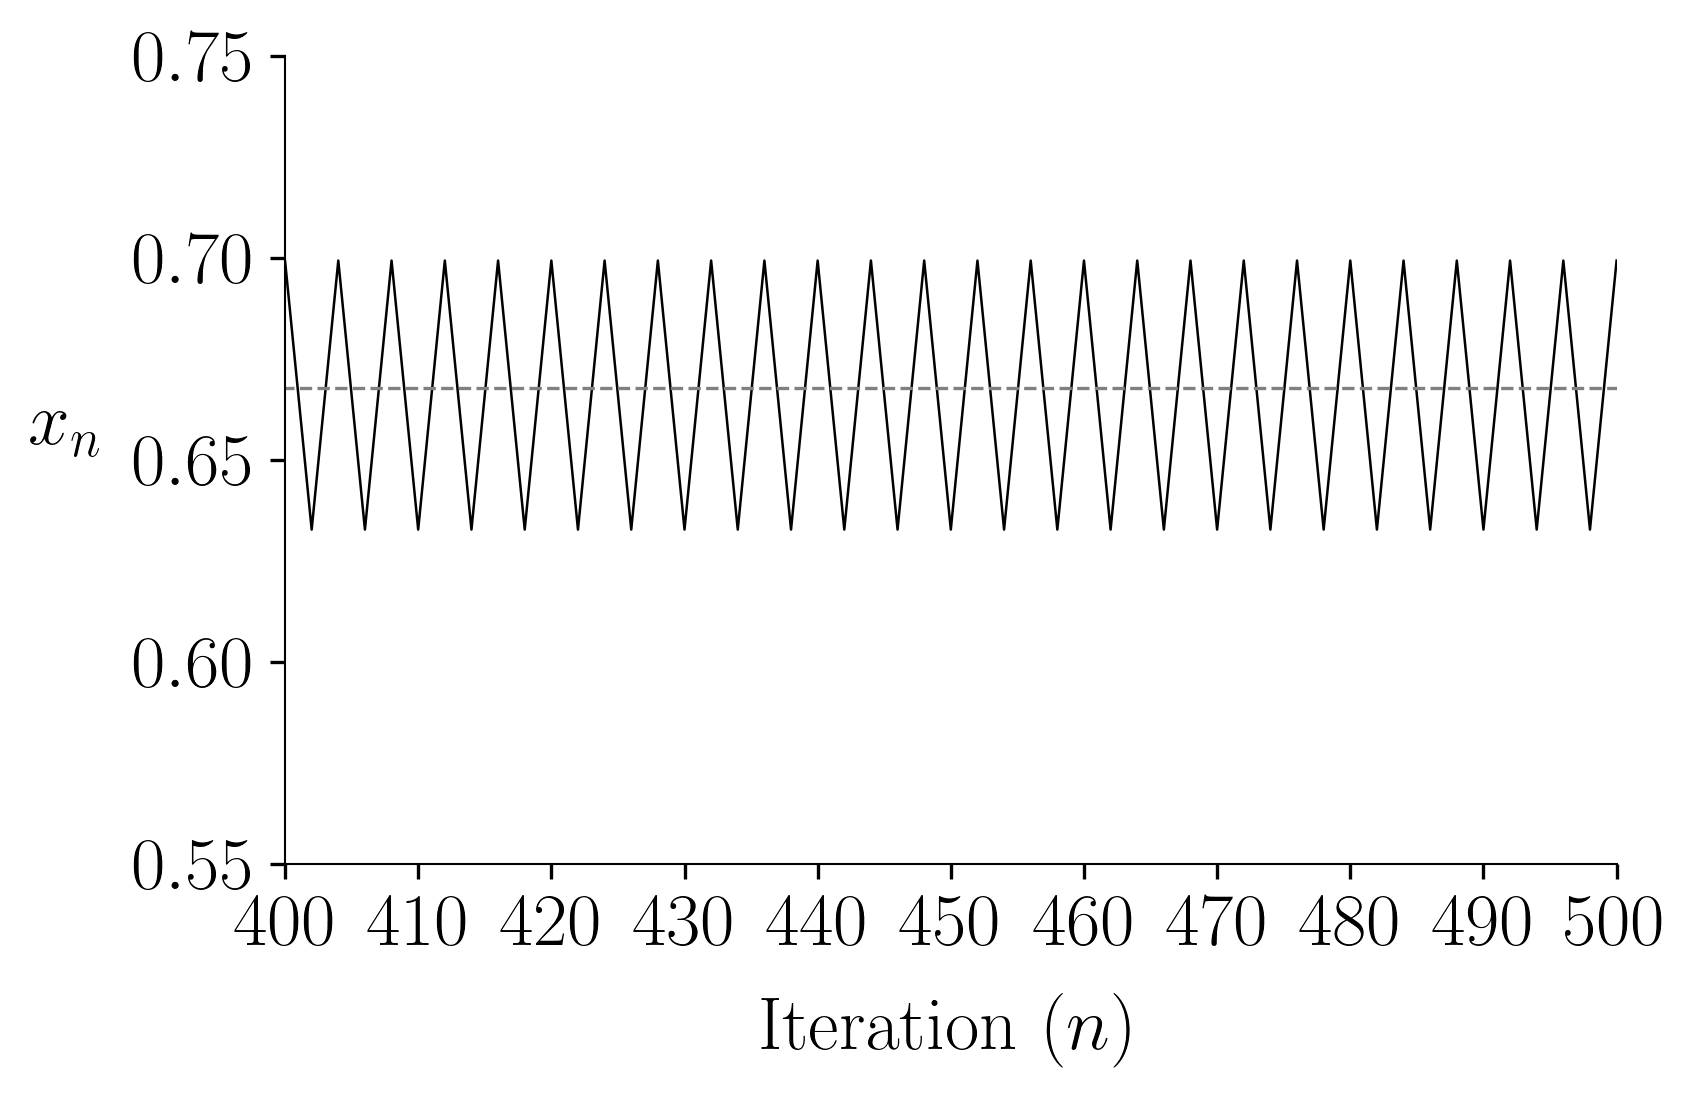

In [4]:
#COBWEB AND ITERATION

#GLOBAL
import numpy as np
from pandas import DataFrame
import matplotlib.pyplot as plt
plt.rcParams.update({"text.usetex":True,
                     "font.family":"serif",
                     "font.size":18,
                     "axes.labelsize":18,
                     "xtick.labelsize":18,
                     "ytick.labelsize":18,
                     "legend.fontsize":20,
                     "lines.markersize":0.3,
                     "figure.dpi":300,
                     "axes.xmargin":0,
                     "axes.ymargin":0,
                     "axes.linewidth":0.5,
                     "axes.spines.top":False,
                     "axes.spines.right":False,
                     "axes.edgecolor":"black"
})

#PARAMETERS
mu = 3.01
x0 = 0.7
niters = 500 #the true number of iterations is half this
f = np.frompyfunc(lambda x:mu*x*(1-x), nin = 1, nout = 1)

#COBWEB
dfrows = [[x0,0],[x0,f(x0)]]
i = 1
while i <= niters:
    dfrows.append([dfrows[i][1],dfrows[i][1]])
    dfrows.append([dfrows[i+1][0],f(dfrows[i+1][1])])
    i += 2
df = DataFrame(dfrows, columns = ["x","y"])

#COBWEB PLOT
fig, ax = plt.subplots(figsize = (6,6))
ax.plot(np.linspace(0,1,500),f(np.linspace(0,1,500)), c = "black", linewidth = 0.6)
ax.plot([0,0.25*mu + 0.1],[0,0.25*mu + 0.1],c = "black", linewidth = 0.6)
ax.plot(df["x"],df["y"],"k--",linewidth = 0.6)
plt.text(df.iloc[0,0]-0.02,-0.03, r"$x_0$", fontsize = 20)
plt.xticks(np.arange(0,1.1,step = 0.2))
ax.set_xlabel(r"$x$", labelpad = 8), ax.set_ylabel(r"$y$", labelpad = 16, rotation = 0)
ax.xaxis.tick_bottom()
fig.tight_layout();
fig.savefig("figs/cobweb_plot.pdf");

#TABLE
#start = 480 #leq niters
#out = DataFrame(df.iloc[start::2,1].reset_index(drop = True))
#out.rename(columns = {"y":r"$x_n$"}, inplace = True)
#out.index = out.index + start + 10
#out.index.name = r"$n$"
#out.to_latex("figs/iteration_table.tex", index = True)

#ITERATION PLOT
fig, ax = plt.subplots(figsize = (6,4))
ax.plot(df.iloc[::2,1], c = "black", linewidth = 0.6)
fp = ax.hlines(max(0,mu-1)/mu, 0, niters, "grey", linestyles = "--", linewidth = 0.8)
ax.set_xlabel(r"Iteration ($n$)", labelpad = 8), ax.set_ylabel(r"$x_n$", labelpad = 16, rotation = 0)
plt.xticks(np.arange(400,niters+1,step = 10)), plt.yticks(np.arange(0.55,0.8,step = 0.05))
ax.set_xlim(400,500)
ax.set_ylim(0.55,0.75)
ax.xaxis.tick_bottom();

#ax.legend(handles = [fp], labels = ["Fixed point"], loc = "best", fontsize = 16)
fig.tight_layout()
fig.savefig("figs/iteration_plot.pdf");

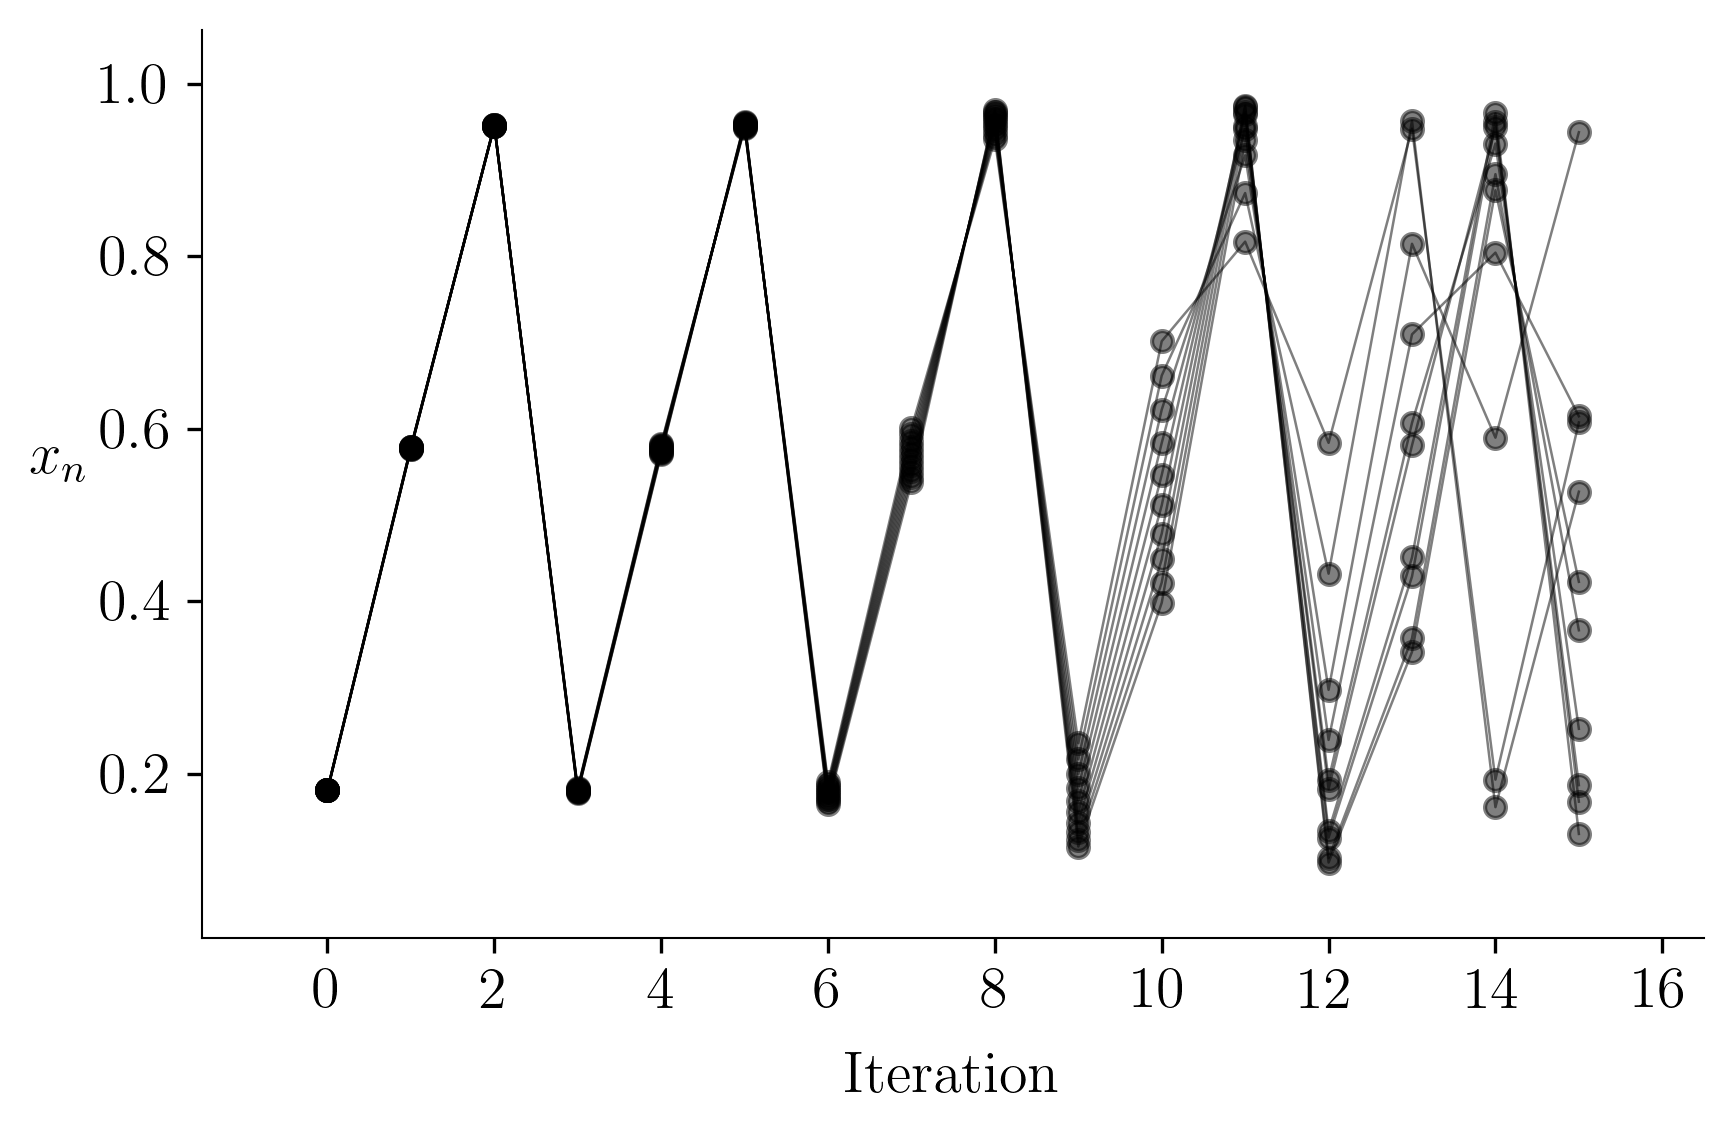

In [46]:
#MULTIPLE PATH ITERATION

#PARAMETERS
mu = 3.9
x0 = 0.1809
niters = 15
npaths = 10
dfrows2 = [[x0 + i*10**-4] for i in range(-npaths//2, npaths//2)]

for i in range(npaths):
    k = 1
    while k <= niters:
        dfrows2[i].append(f(dfrows2[i][k-1]))
        k += 1

#PLOT
fig, ax = plt.subplots(figsize = (6,4))
for ys in dfrows2:
    ax.plot(ys, marker = "o", markersize = 5, c = "black", alpha = 0.5, linewidth = 0.6)

ax.set_xlabel("Iteration", labelpad = 8), ax.set_ylabel(r"$x_n$", labelpad = 10, rotation = 0)
plt.xticks(np.arange(0,17,step = 2))
ax.xaxis.tick_bottom()
fig.tight_layout();
fig.savefig("figs/multiple_path.pdf");

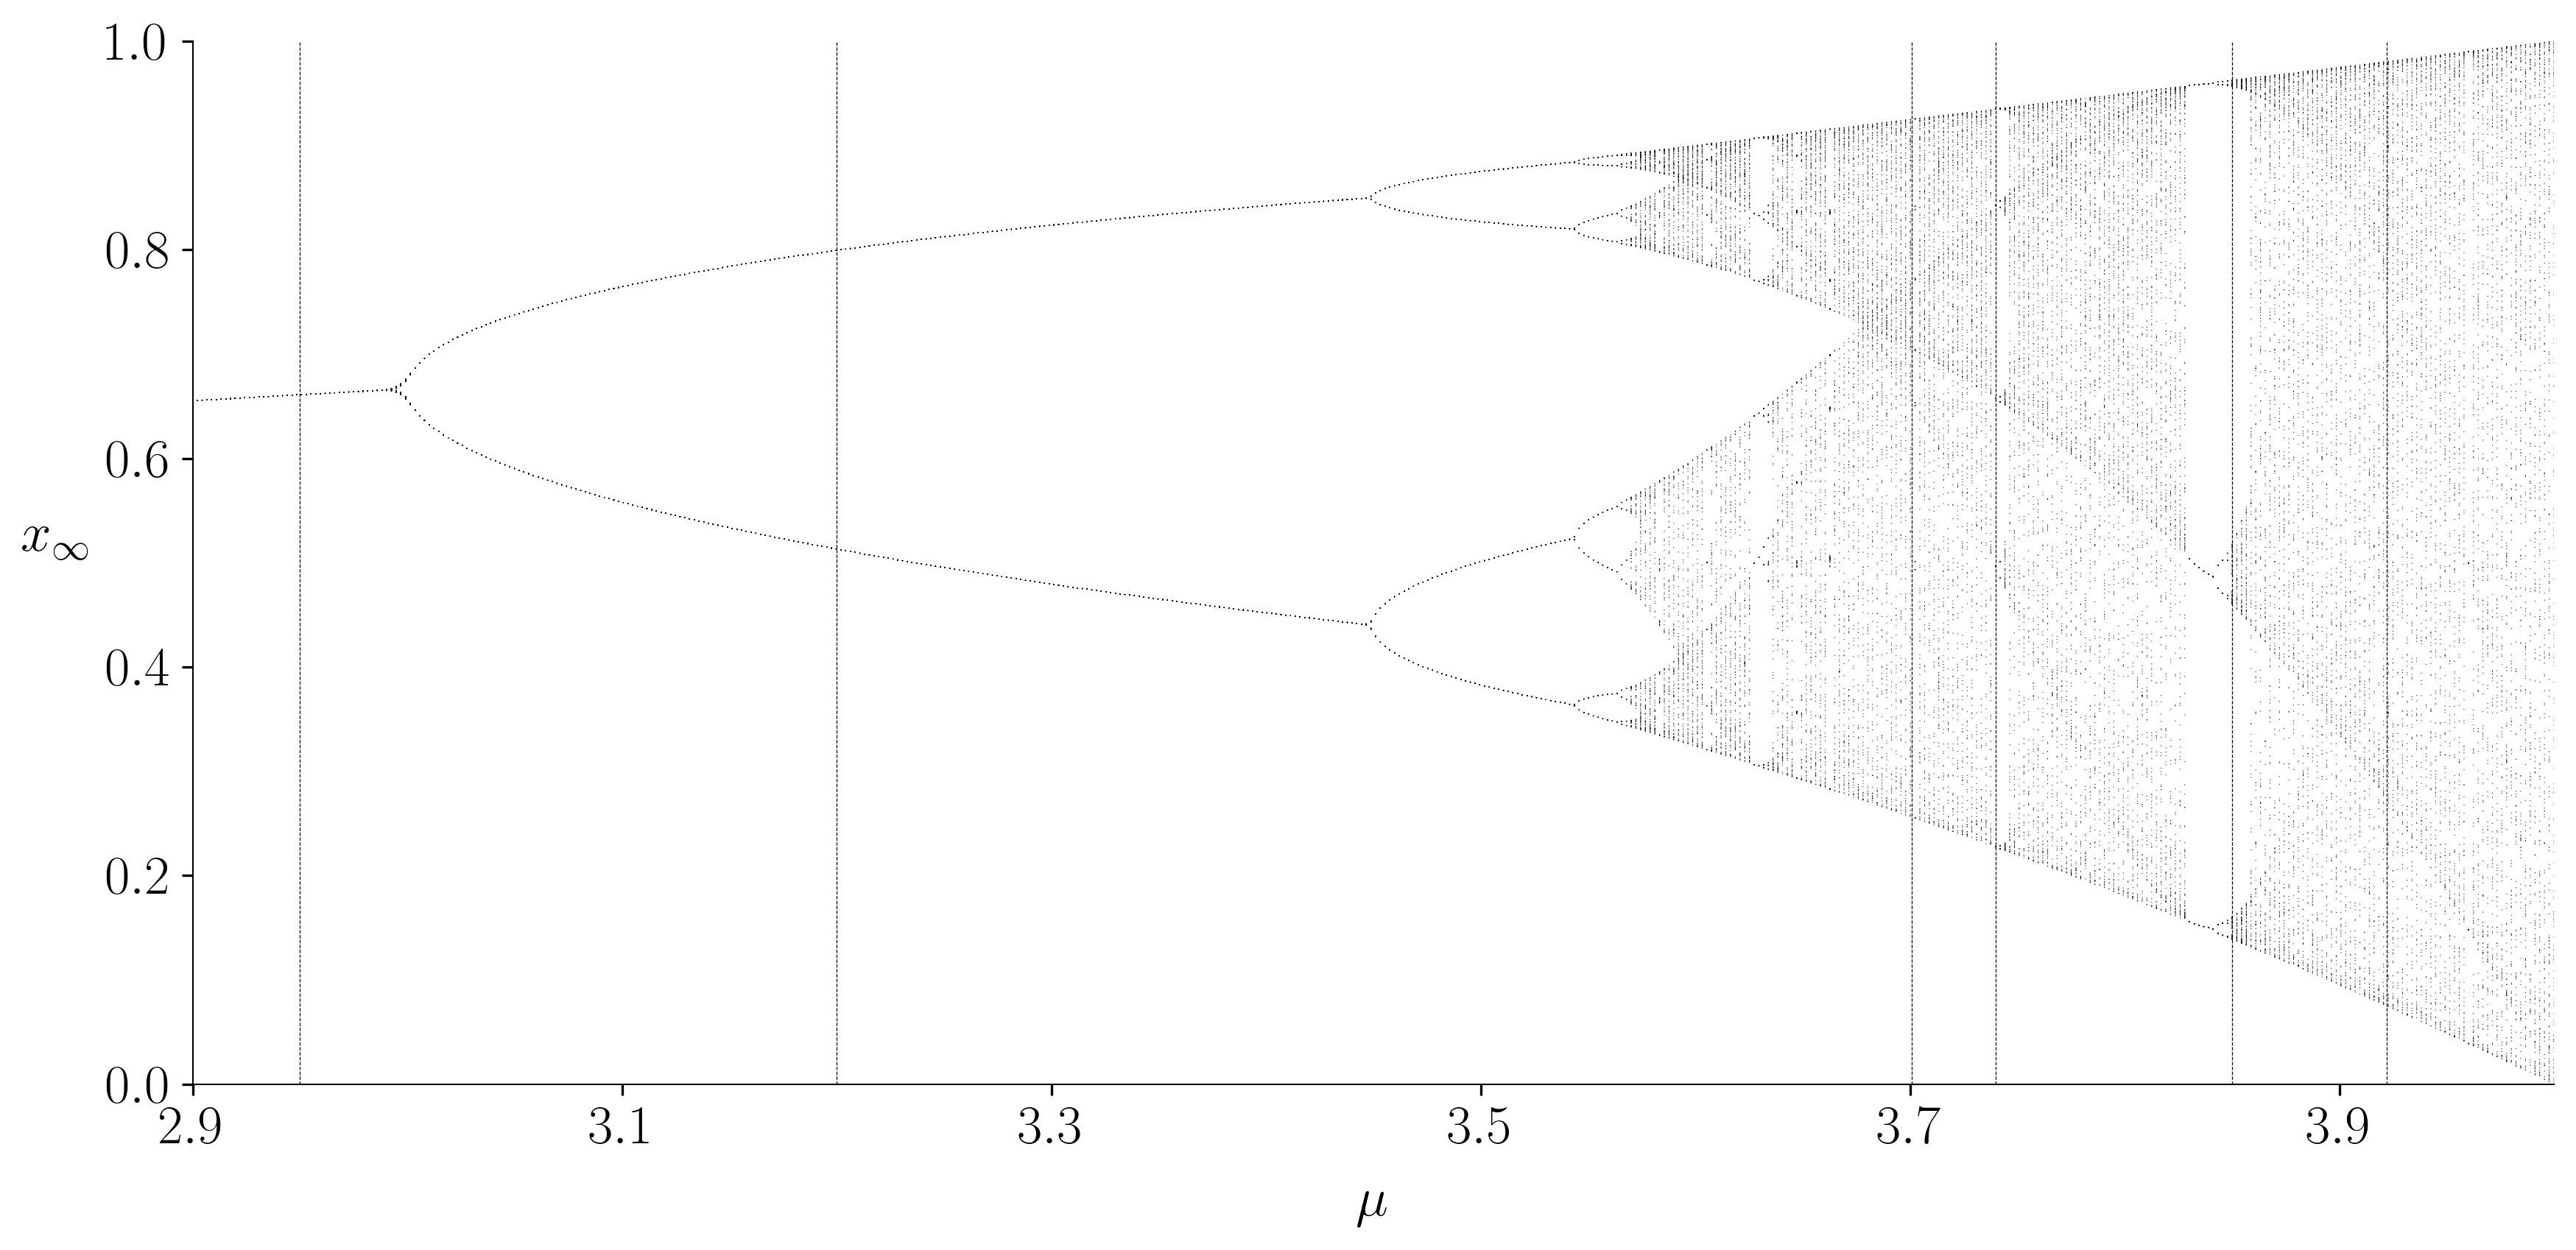

In [7]:
#GENERAL BIFURCATION

niter = 600
niter_keep = 200
mu_range = np.linspace(2.9, 4, 500)
stable_regions = [2.95, 3.2, 3.74, 3.85, 3.922, 3.701]

df_bifrows = {}
for mu in mu_range:
    x_np1 = 0.1
    df_bifrows[mu] = [x_np1]
    for i in range(niter):
        x_np1 = f(x_np1)
        if i > niter - niter_keep:
            df_bifrows[mu].append(x_np1)
df_bif = DataFrame(df_bifrows)

#PLOT
fig, ax = plt.subplots(figsize=(12, 6))
for col in df_bif.iloc[:, :]:
    ax.scatter([col] * (niter_keep - 1), df_bif.loc[1:, col], c="#000000", edgecolors="none",
               s=0.08)  #using .loc here isn't great

#for i, mu in enumerate(period3_bifurcations):
#    ax.plot(np.linspace(mu, mu, 100), np.linspace(0, 1, 100), "--k", linewidth=0.3)

for mu in stable_regions:
    ax.plot(np.linspace(mu,mu,100), np.linspace(0,1,100), "--k", linewidth = 0.3)

ax.set_xlabel(r"$\mu$", labelpad=8), ax.set_ylabel(r"$x_\infty$", labelpad=16, rotation=0)
plt.xticks(np.arange(2.9, 4.01, step=0.2))
ax.xaxis.tick_bottom()
fig.tight_layout()
plt.show;
#fig.savefig("figs/bifurcation_plot.png");

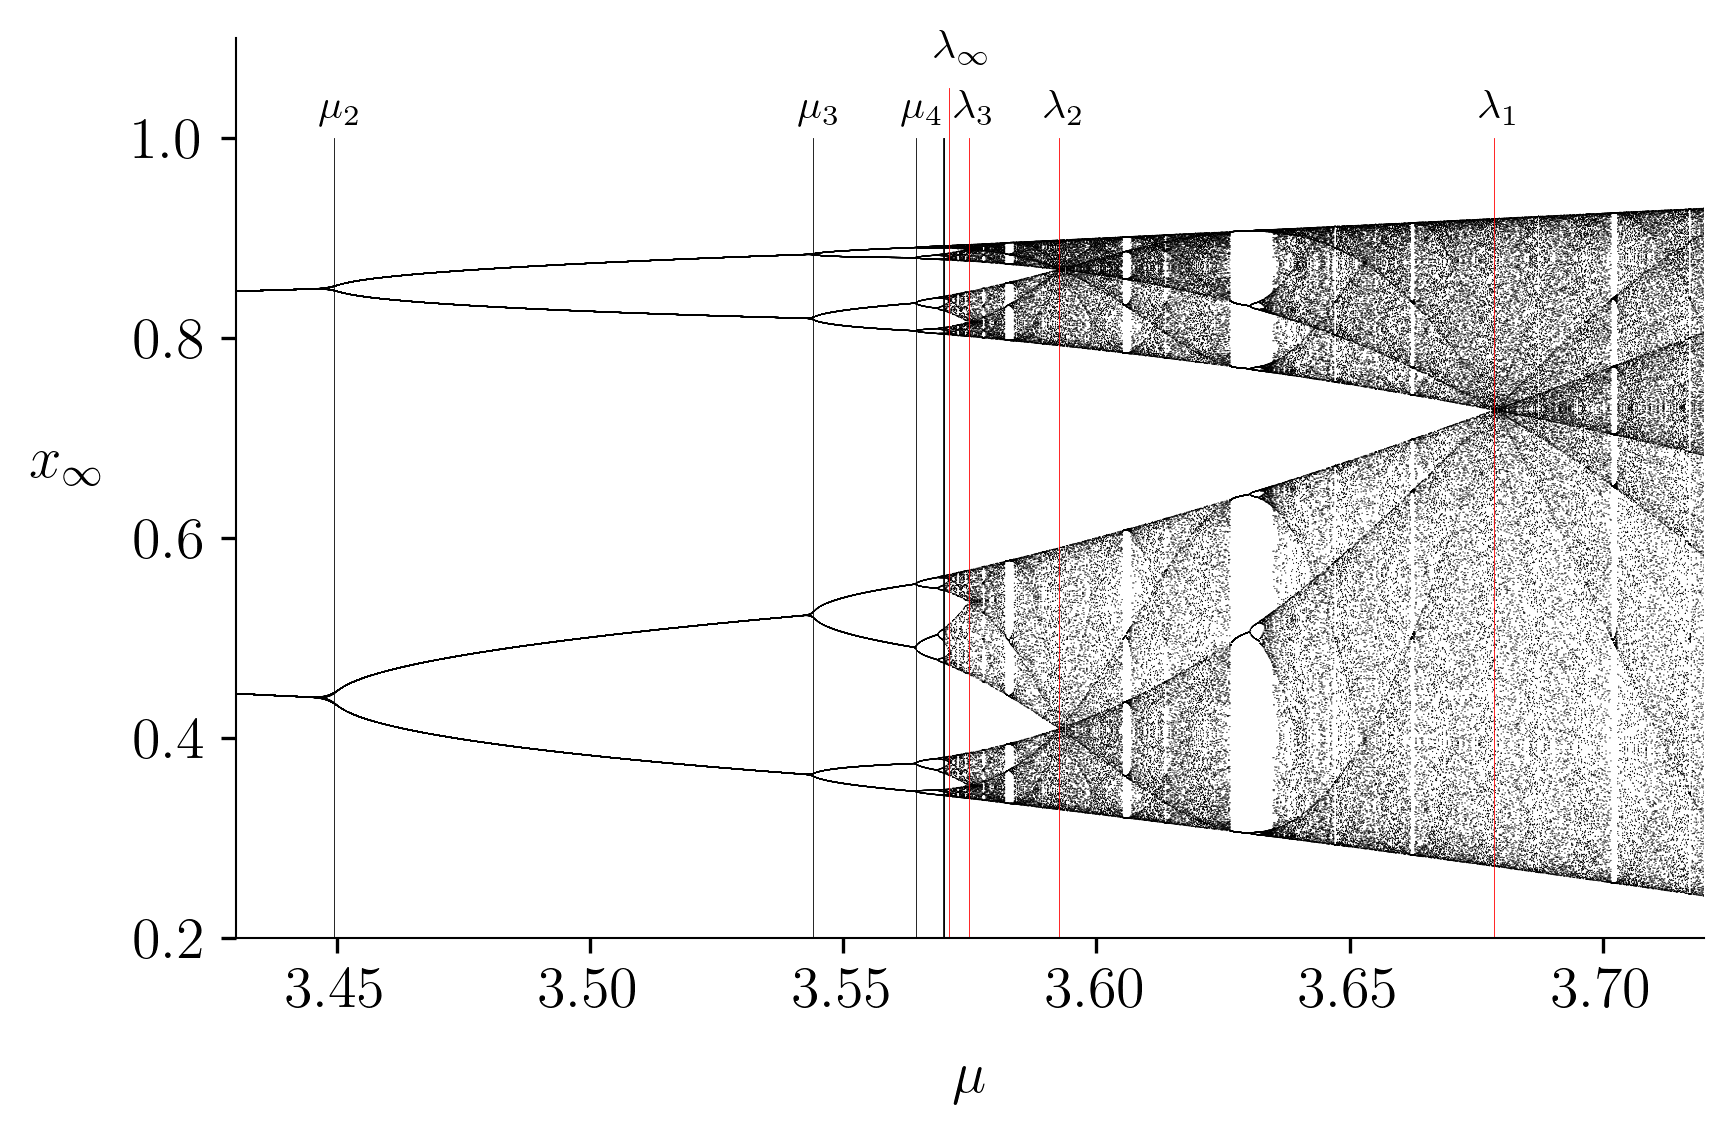

In [33]:
#BIFURCATION PARAMETERS

niter = 600
niter_keep = 200
mu_range = np.linspace(3.43,3.72,1500)
mu_bifurcations = [3.44948, 3.54409, 3.56440, 3.56969, 3.56989, 3.56994567187303759328]
lambda_bifurcations = [3.67857351042832226, 3.59257, 3.5748, 3.5709]

df_bifrows = {}
for mu in mu_range:
    x_np1 = 0.1
    df_bifrows[mu] = [x_np1]
    for i in range(niter):
        x_np1 = f(x_np1)
        if i > niter-niter_keep:
            df_bifrows[mu].append(x_np1)
df_bif = DataFrame(df_bifrows)

#PLOT
fig, ax = plt.subplots(figsize = (6,4))
for col in df_bif.iloc[:,:]:
    ax.scatter([col]*(niter_keep-1), df_bif.loc[1:, col], c = "#000000",edgecolors = "none", s = 0.08) #using .loc here isn't great

#MU
for i, mu in enumerate(mu_bifurcations):
    ax.plot(np.linspace(mu, mu, 100), np.linspace(0, 1, 100), "-k", linewidth = 0.2)
    plt.text(mu-0.003, 1.02, rf"$\mu_{{{i+2}}}$" if i < len(mu_bifurcations)-3 else "", fontsize = 10)

#LAMBDA
for i, lam in enumerate(lambda_bifurcations):
    ax.plot(np.linspace(lam,lam,100), np.linspace(0, 1 if i < len(lambda_bifurcations)-1 else 1.05, 100), "-r", linewidth = 0.2)
    plt.text(lam-0.003, 1.02 if i < len(lambda_bifurcations)-1 else 1.08, rf"$\lambda_{{{i+1}}}$" if i < len(lambda_bifurcations)-1 else rf"$\lambda_\infty$",fontsize = 10)

ax.set_xlabel(r"$\mu$", labelpad = 8), ax.set_ylabel(r"$x_\infty$", labelpad = 16, rotation = 0)
plt.xticks(np.arange(3.45,3.71,step = 0.05))
ax.set_ylim(0.2,1.1)
ax.xaxis.tick_bottom()
fig.tight_layout()
plt.show;
fig.savefig("figs/bifurcation_parameters.png");

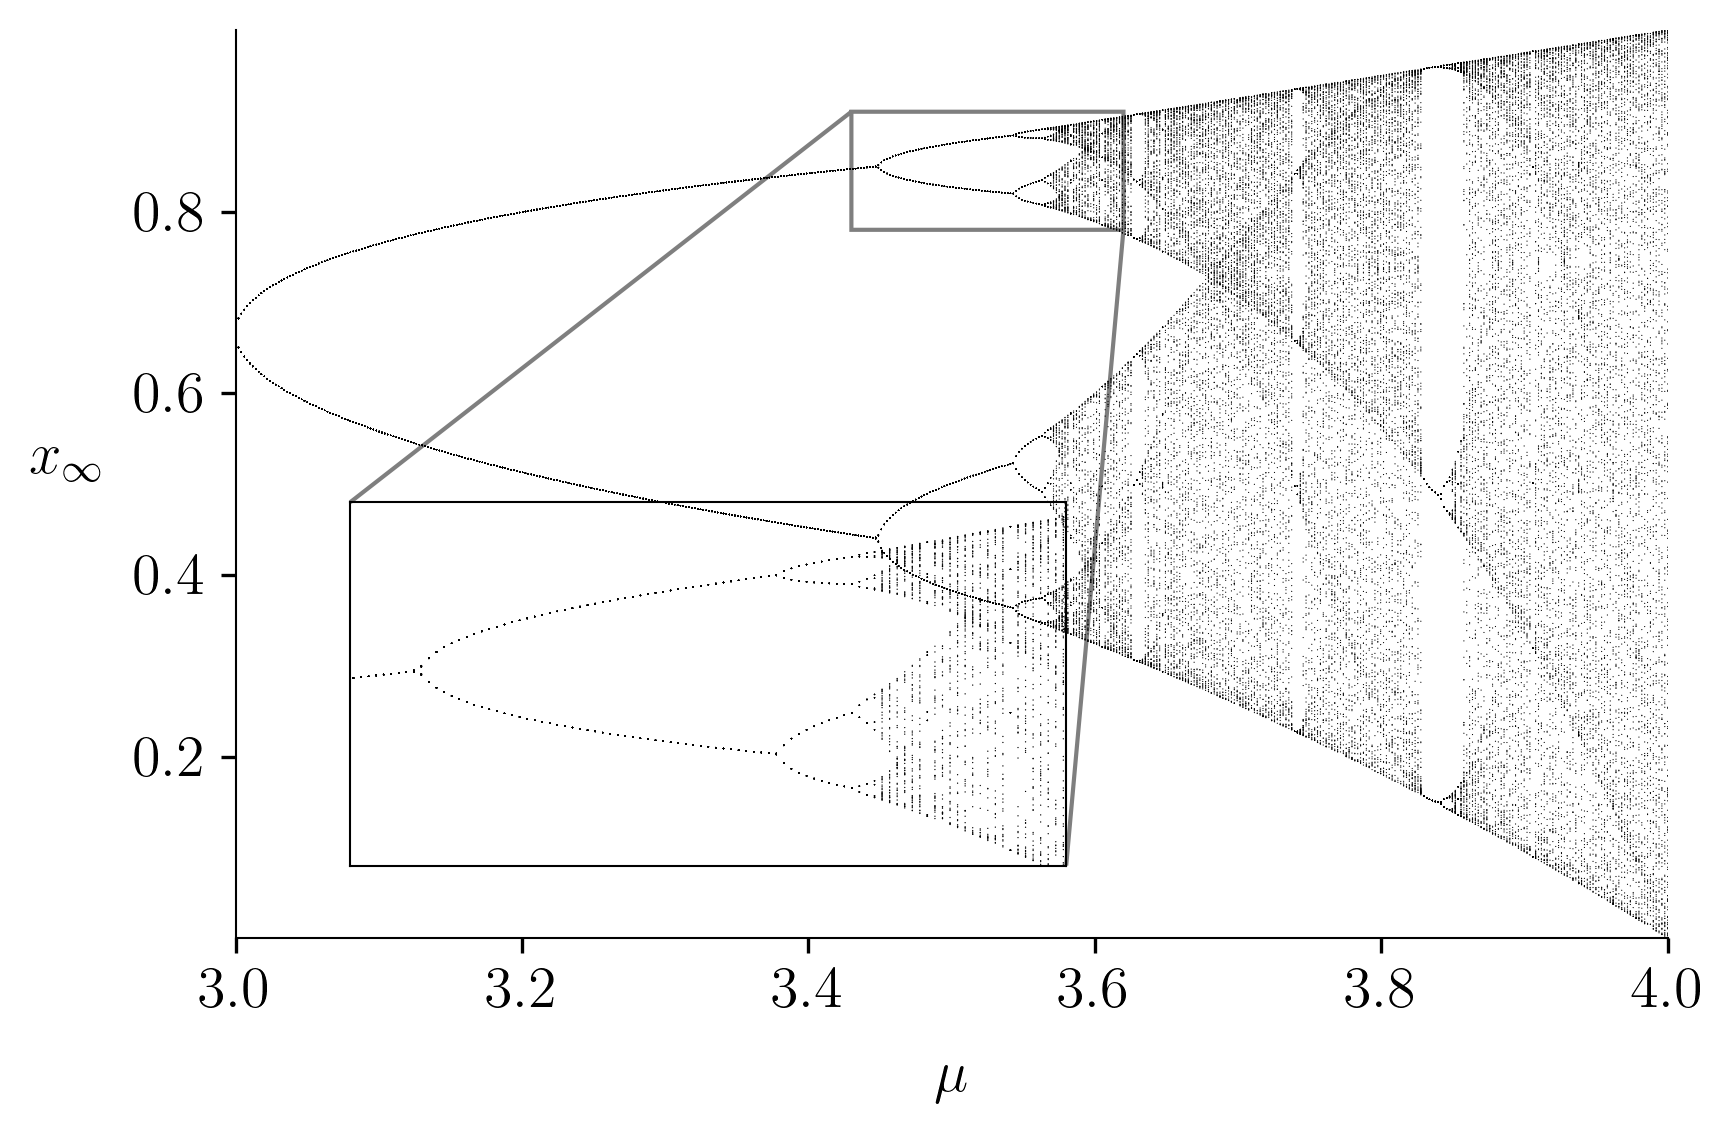

In [34]:
#BIFURCATION PIP

niter = 600
niter_keep = 200
mu_range = np.linspace(2.8,4,500)

df_bifrows = {}
for mu in mu_range:
    x_np1 = 0.1
    df_bifrows[mu] = [x_np1]
    for i in range(niter):
        x_np1 = f(x_np1)
        if i > niter-niter_keep:
            df_bifrows[mu].append(x_np1)
df_bif = DataFrame(df_bifrows)

#PLOT
fig, ax = plt.subplots(figsize = (6,4))
axins = ax.inset_axes([0.08,0.08,0.5,0.4])
axins.spines['top'].set_visible(True)
axins.spines['right'].set_visible(True)
for col in df_bif.iloc[:,:]:
    ax.scatter([col]*(niter_keep-1), df_bif.loc[1:, col], c = "#000000",edgecolors = "none", s = 0.08) #using .loc here isn't great
    axins.scatter([col]*(niter_keep-1), df_bif.loc[1:, col], c = "#000000", edgecolors = "none", s = 0.1)

#PICTURE IN PICTURE
x1,x2,y1,y2 = 3.43,3.62,0.78,0.91
axins.set_xlim(x1, x2), axins.set_ylim(y1, y2)

axins.set_xticklabels([]), axins.set_yticklabels([])
axins.set_xticks([]), axins.set_yticks([])
ax.indicate_inset_zoom(axins, edgecolor="black")
axins.patch.set_alpha(0)

ax.set_xlabel(r"$\mu$", labelpad = 8), ax.set_ylabel(r"$x_\infty$", labelpad = 16, rotation = 0)
ax.xaxis.tick_bottom()
fig.tight_layout()
plt.show;
fig.savefig("figs/bifurcation_pip.png");

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ollie\AppData\Local\Temp\ipykernel_672\751148584.py:12: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(np.linspace(0,1,500),f(np.linspace(0,1,500)), linewidth = 0.6, label = f"$y = {{{mu}}}\\sin(\pi x)$")


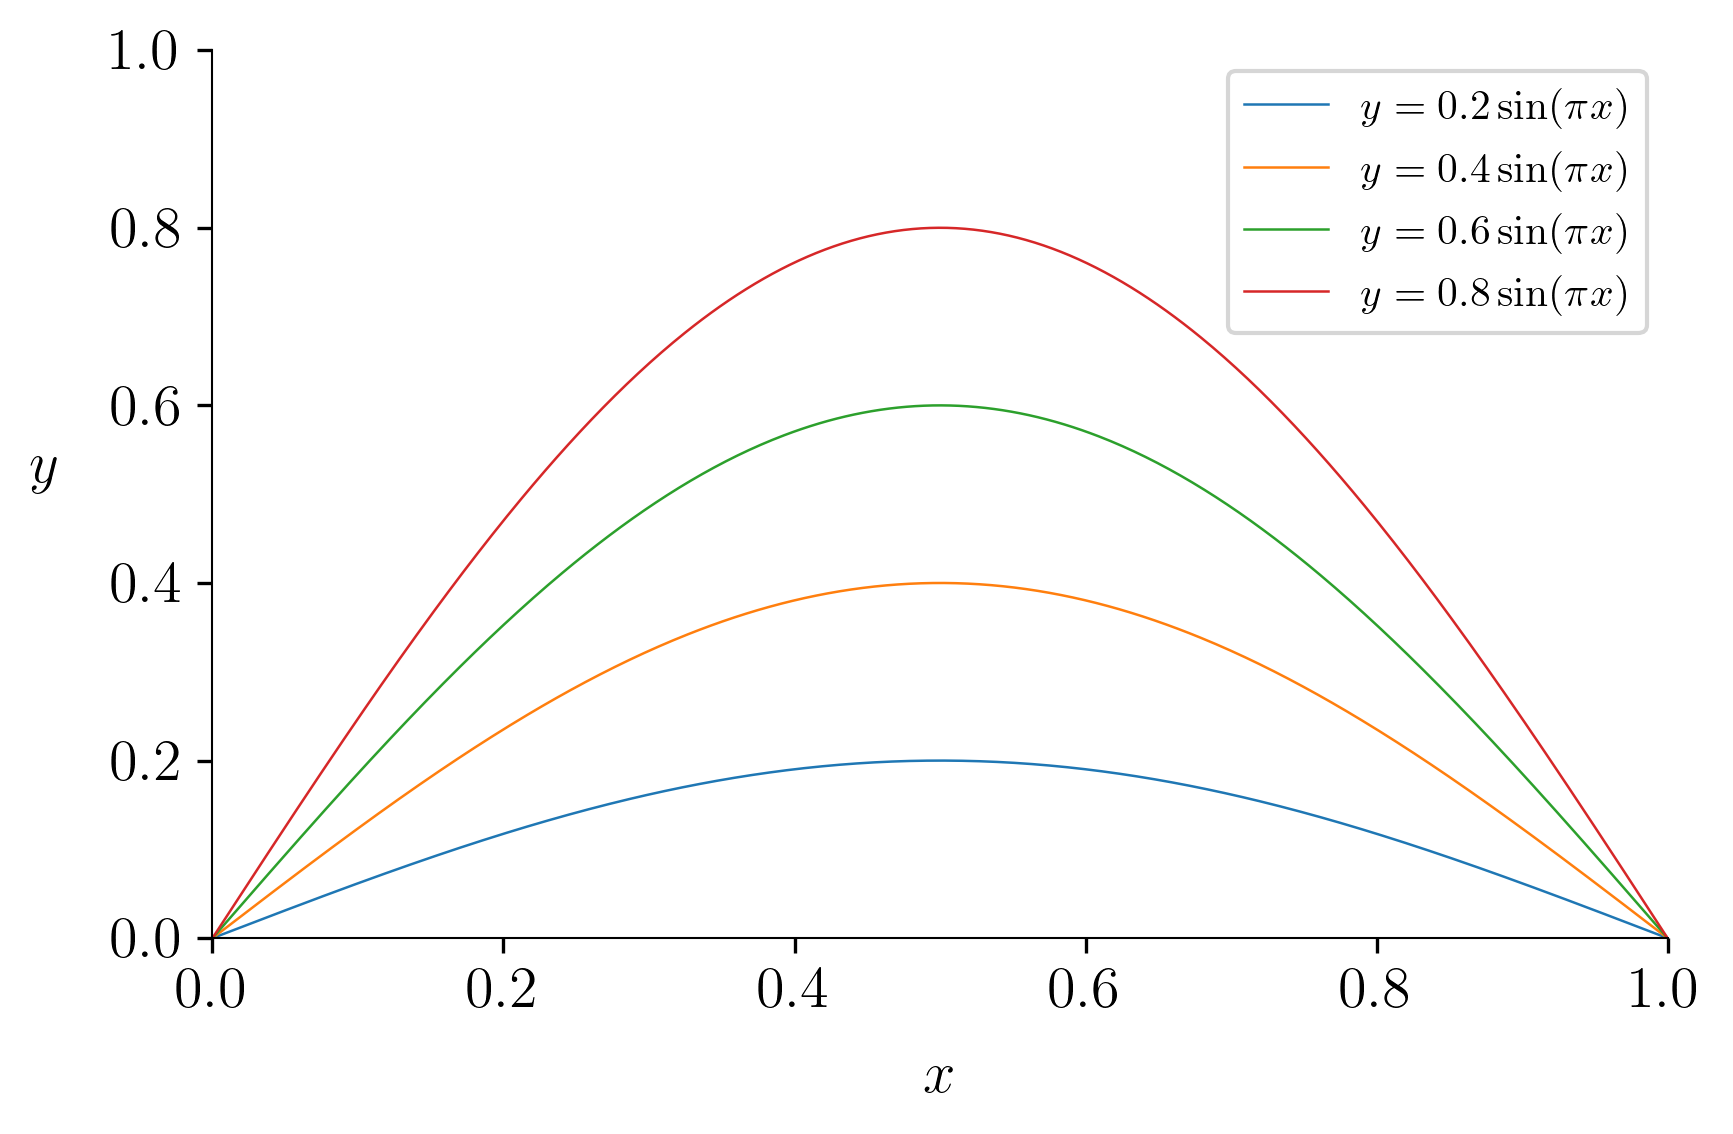

In [35]:
#MULTI-MAP

#PARAMETERS
mus = [0.2,0.4,0.6,0.8]
f = np.frompyfunc(lambda x:mu*np.sin(np.pi*x), nin = 1, nout = 1) #SINE
#= np.frompyfunc(lambda x:mu*x*(1-x), nin = 1, nout = 1) #LOGISTIC


#PLOT
fig, ax = plt.subplots(figsize = (6,4))
for mu in mus:
    ax.plot(np.linspace(0,1,500),f(np.linspace(0,1,500)), linewidth = 0.6, label = rf"$y = {{{mu}}}\\sin(\pi x)$")
plt.xticks(np.arange(0,1.1,step = 0.2))
plt.yticks(np.arange(0,1.1,step = 0.2))
ax.legend(fontsize = 10)
ax.set_xlabel(r"$x$", labelpad = 8), ax.set_ylabel(r"$y$", labelpad = 16, rotation = 0)
ax.xaxis.tick_bottom()
fig.tight_layout();
fig.savefig("figs/multi_plot.pdf");

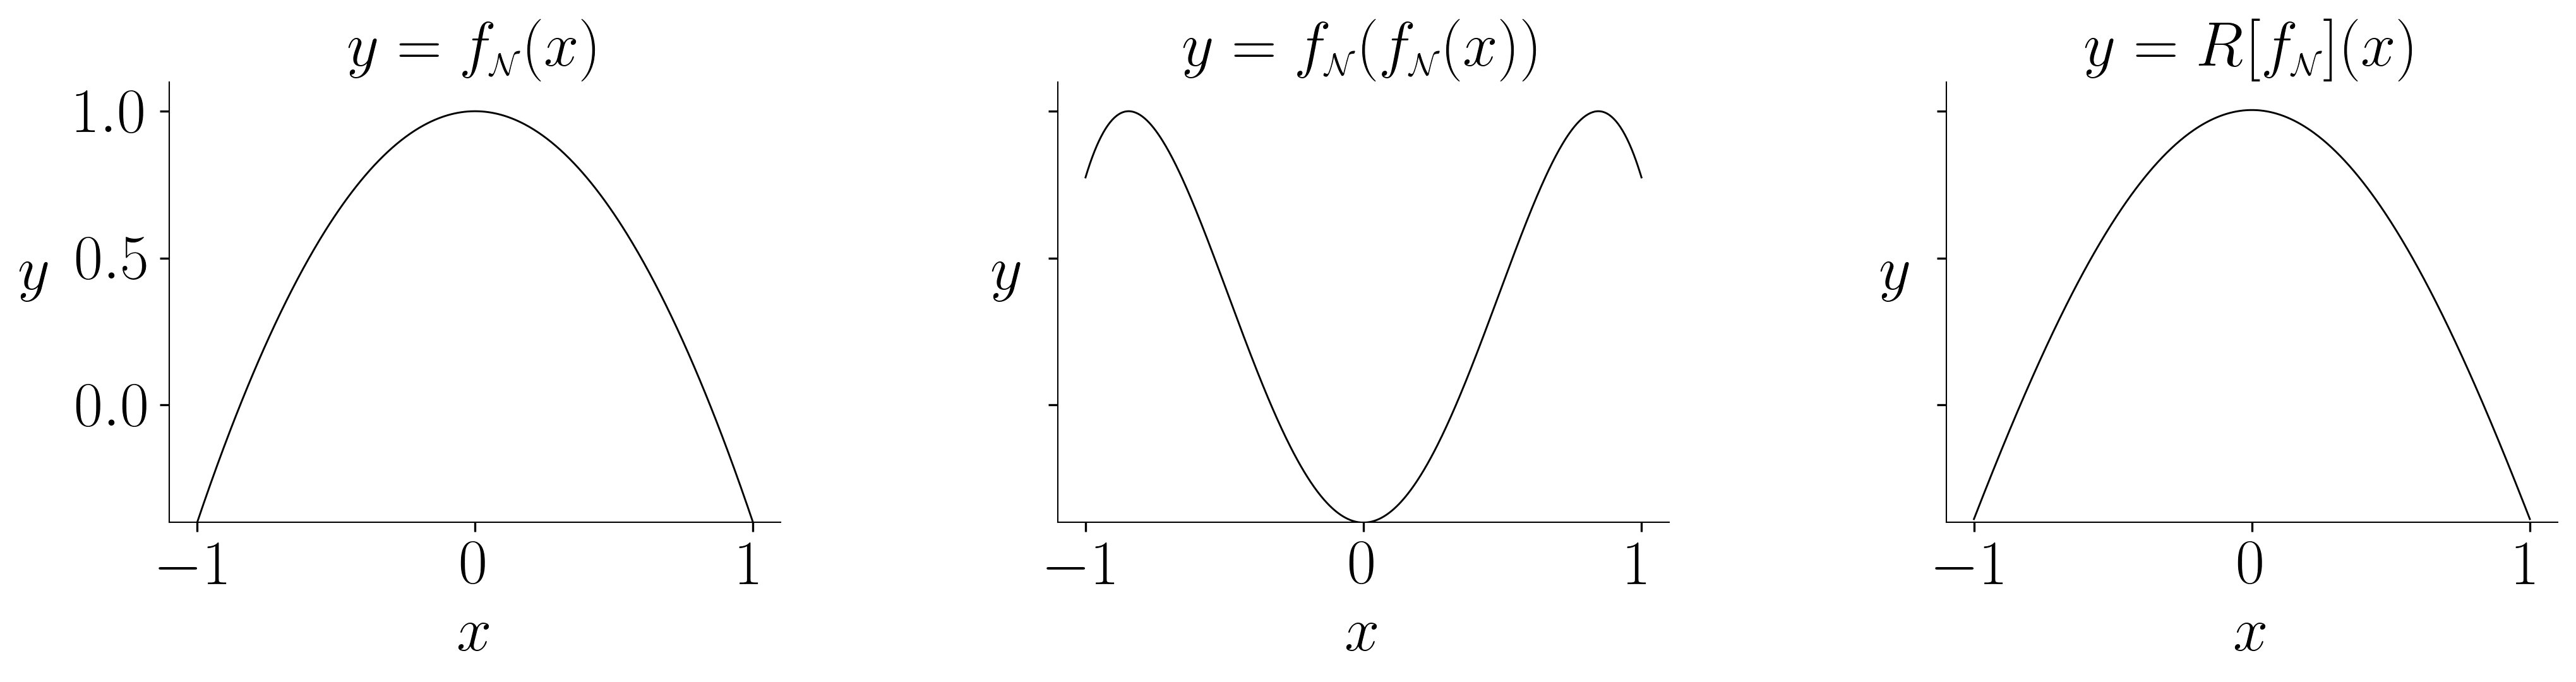

In [2]:
#RENORMALISATION FLOWCHART

#PARAMETERS
mu = 3.56994567187303759328
alpha = -2.50290787509589
f = np.frompyfunc(lambda x:1-(mu*(mu-2)/4)*x**2, nin = 1, nout = 1) #NORMALISED LOGISTIC
def R(func,n):
    for _ in range(n):
        func = lambda x, f=func: alpha*(f(f(x/alpha)))
    return func
n = 1

#PLOT
fig, axs = plt.subplots(1,3,figsize = (14,4), sharey = True)

axs[0].plot(np.linspace(-1,1,500),f(np.linspace(-1,1,500)), linewidth = 0.7, c = "black", label = r"$y = f_\mathcal{\scriptscriptstyle N}(x)$")
axs[1].plot(np.linspace(-1,1,500),f(f(np.linspace(-1,1,500))), linewidth = 0.7, c = "black", label = r"$y = f_\mathcal{\scriptscriptstyle N}(f_n(x))$")
axs[2].plot(np.linspace(-1,1,500),R(f,n)(np.linspace(-1,1,500)), linewidth = 0.7, c = "black", label = rf"$y = R^{{{"" if n == 1 else (n)}}}[f_\mathcal{{\scriptscriptstyle N}}](x)$")

titles = [r"$y = f_\mathcal{\scriptscriptstyle N}(x)$", r"$y = f_\mathcal{\scriptscriptstyle N}(f_\mathcal{\scriptscriptstyle N}(x))$", rf"$y = R^{{{"" if n == 1 else (n)}}}[f_\mathcal{{\scriptscriptstyle N}}](x)$"]

for ax,title in zip(axs,titles):
    ax.set_xlabel(r"$x$", labelpad = 4), ax.set_ylabel(r"$y$", labelpad = 16, rotation = 0)
    ax.set_xlim(-1.1,1.1), ax.set_ylim(-0.4,1.1)
    ax.xaxis.tick_bottom()
    ax.set_title(title)

fig.tight_layout(w_pad = 4);
fig.savefig("figs/renormalisation_flowchart.pdf");